In [1]:
import pandas as pd
import seaborn as sns
import pandas as pn

In [2]:
data = pd.read_csv('CC GENERAL.csv')
data.shape

(8950, 18)

In [3]:
data.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [5]:
data.dtypes

CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object

In [6]:
# Check for null values and handle those values.


In [7]:
# Check and understand the null values
data.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [8]:
# Check the percentage of missing values

missing = pd.DataFrame({
    'Missing_Count': data.isnull().sum(),
    'Missing_Percentage': data.isnull().mean() * 100
})

missing[missing['Missing_Count'] > 0]

,Missing_Count,Missing_Percentage
CREDIT_LIMIT,1,0.011173
MINIMUM_PAYMENTS,313,3.497207


In [9]:
data['CREDIT_LIMIT'].fillna(data['CREDIT_LIMIT'].median(),inplace=True)

C:\Users\UTL2397\AppData\Local\Temp\ipykernel_17032\218506383.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['CREDIT_LIMIT'].fillna(data['CREDIT_LIMIT'].median(),inplace=True)


0       1000.0
1       7000.0
2       7500.0
3       7500.0
4       1200.0
         ...  
8945    1000.0
8946    1000.0
8947    1000.0
8948     500.0
8949    1200.0
Name: CREDIT_LIMIT, Length: 8950, dtype: float64

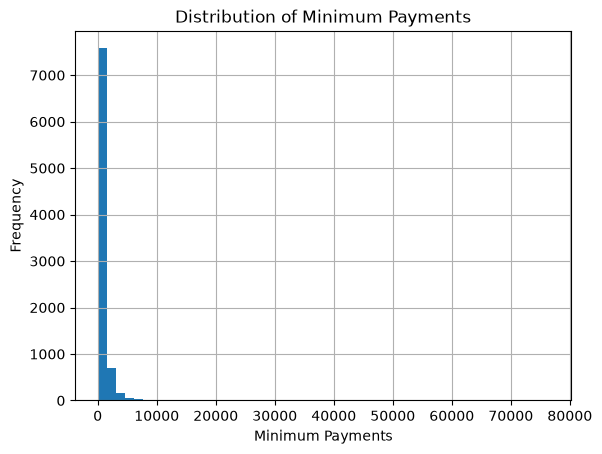

0        139.509787
1       1072.340217
2        627.284787
3               NaN
4        244.791237
           ...     
8945      48.886365
8946            NaN
8947      82.418369
8948      55.755628
8949      88.288956
Name: MINIMUM_PAYMENTS, Length: 8950, dtype: float64

In [10]:
import matplotlib.pyplot as plt

data["MINIMUM_PAYMENTS"].hist(bins=50)

plt.xlabel("Minimum Payments")
plt.ylabel("Frequency")
plt.title("Distribution of Minimum Payments")
plt.show()
data["MINIMUM_PAYMENTS"]

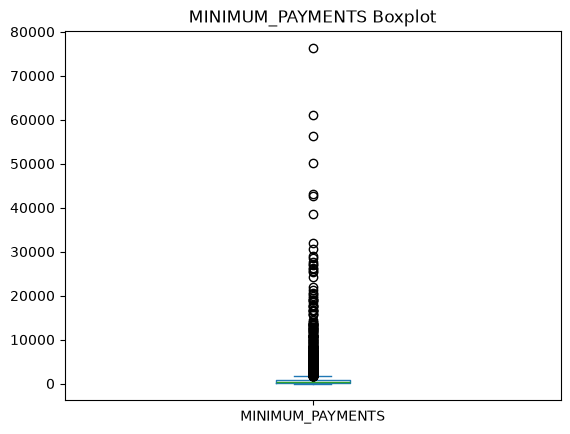

In [11]:
data["MINIMUM_PAYMENTS"].plot(kind="box")

plt.title("MINIMUM_PAYMENTS Boxplot")
plt.show()

In [12]:
data["MINIMUM_PAYMENTS_MISSING"] = data["MINIMUM_PAYMENTS"].isnull()

In [13]:
data.groupby("MINIMUM_PAYMENTS_MISSING")[
    ["BALANCE", "PURCHASES", "CASH_ADVANCE", "PAYMENTS", "CREDIT_LIMIT"]
].mean()

,BALANCE,PURCHASES,CASH_ADVANCE,PAYMENTS,CREDIT_LIMIT
MINIMUM_PAYMENTS_MISSING,,,,,
False,1601.041632,1025.315149,994.082050,1784.272537,4522.091030
True,555.441321,393.087284,559.136698,322.286168,3731.789137


In [14]:
data[["MINIMUM_PAYMENTS", "PAYMENTS", "BALANCE", "CREDIT_LIMIT"]].corr()

,MINIMUM_PAYMENTS,PAYMENTS,BALANCE,CREDIT_LIMIT
MINIMUM_PAYMENTS,1.000000,0.126651,0.398684,0.126671
PAYMENTS,0.126651,1.000000,0.322802,0.421861
BALANCE,0.398684,0.322802,1.000000,0.531283
CREDIT_LIMIT,0.126671,0.421861,0.531283,1.000000


In [15]:
data.groupby("MINIMUM_PAYMENTS_MISSING")["BALANCE"].describe()

,count,mean,std,min,25%,50%,75%,max
MINIMUM_PAYMENTS_MISSING,,,,,,,,
False,8637.0,1601.041632,2095.519182,0.0,147.838347,916.749476,2104.961701,19043.138560
True,313.0,555.441321,1292.687887,0.0,0.187069,16.848358,286.686616,9164.724752


In [16]:
data.groupby("MINIMUM_PAYMENTS_MISSING")["PAYMENTS"].describe()

,count,mean,std,min,25%,50%,75%,max
MINIMUM_PAYMENTS_MISSING,,,,,,,,
False,8637.0,1784.272537,2909.704331,0.049513,418.446951,896.300688,1951.116757,50721.48336
True,313.0,322.286168,1996.658905,0.000000,0.000000,0.000000,0.000000,29272.48607


In [17]:
data.groupby("MINIMUM_PAYMENTS_MISSING")["CREDIT_LIMIT"].describe()

,count,mean,std,min,25%,50%,75%,max
MINIMUM_PAYMENTS_MISSING,,,,,,,,
False,8636.0,4522.091030,3659.240379,50.0,1600.0,3000.0,6500.0,30000.0
True,313.0,3731.789137,2924.606153,500.0,1500.0,3000.0,5000.0,19500.0


In [18]:
data["MINIMUM_PAYMENTS"].describe()

count     8637.000000
mean       864.206542
std       2372.446607
min          0.019163
25%        169.123707
50%        312.343947
75%        825.485459
max      76406.207520
Name: MINIMUM_PAYMENTS, dtype: float64

In [19]:
data["MINIMUM_PAYMENTS"] = data["MINIMUM_PAYMENTS"].fillna(data["MINIMUM_PAYMENTS"].median())
data["CREDIT_LIMIT"] = data["CREDIT_LIMIT"].fillna(data["CREDIT_LIMIT"].median())

In [20]:
data.isnull().sum()

CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
MINIMUM_PAYMENTS_MISSING            0
dtype: int64

In [21]:
data.isnull().sum().sum()

np.int64(0)

In [22]:
data.drop(columns=["MINIMUM_PAYMENTS_MISSING"], inplace=True)

In [23]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Remove customer ID
X = data.drop(columns=["CUST_ID"])

# Create scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

# Check the scaled data
X_scaled.head()

print("Mean:")
print(X_scaled.mean())

print("\nStandard deviation:")
print(X_scaled.std())

Mean:
BALANCE                             8.891708e-17
BALANCE_FREQUENCY                   2.286439e-16
PURCHASES                           0.000000e+00
ONEOFF_PURCHASES                    3.175610e-17
INSTALLMENTS_PURCHASES              2.540488e-17
CASH_ADVANCE                        1.016195e-16
PURCHASES_FREQUENCY                -1.841854e-16
ONEOFF_PURCHASES_FREQUENCY         -8.891708e-17
PURCHASES_INSTALLMENTS_FREQUENCY    4.604634e-17
CASH_ADVANCE_FREQUENCY              5.557317e-17
CASH_ADVANCE_TRX                   -2.540488e-17
PURCHASES_TRX                      -2.540488e-17
CREDIT_LIMIT                        1.270244e-16
PAYMENTS                           -3.810732e-17
MINIMUM_PAYMENTS                    5.716098e-17
PRC_FULL_PAYMENT                    0.000000e+00
TENURE                              2.794537e-16
dtype: float64

Standard deviation:
BALANCE                             1.000056
BALANCE_FREQUENCY                   1.000056
PURCHASES                          

In [24]:
# Perform PCA with all the columns and plot number of components vs. PCA cumulative 
# explained variance. From the plot, identify the number of components required to cover 
# 85% of the variance

from sklearn.decomposition import PCA
pca = PCA(n_components=None)


In [25]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [26]:
pca.explained_variance_ratio_

array([2.72976713e-01, 2.03137796e-01, 8.81318170e-02, 7.47952439e-02,
       6.22472925e-02, 5.74005645e-02, 4.88342555e-02, 4.29920325e-02,
       3.79825870e-02, 3.08000227e-02, 2.37225104e-02, 1.77336964e-02,
       1.42785685e-02, 1.21691956e-02, 1.01266703e-02, 2.67034839e-03,
       6.85226796e-07])

In [27]:
pca.explained_variance_ratio_ * 100

array([2.72976713e+01, 2.03137796e+01, 8.81318170e+00, 7.47952439e+00,
       6.22472925e+00, 5.74005645e+00, 4.88342555e+00, 4.29920325e+00,
       3.79825870e+00, 3.08000227e+00, 2.37225104e+00, 1.77336964e+00,
       1.42785685e+00, 1.21691956e+00, 1.01266703e+00, 2.67034839e-01,
       6.85226796e-05])

In [31]:
cumulative_variance = pca.explained_variance_ratio_.cumsum()
cumulative_variance

array([0.27297671, 0.47611451, 0.56424633, 0.63904157, 0.70128886,
       0.75868943, 0.80752368, 0.85051572, 0.8884983 , 0.91929833,
       0.94302084, 0.96075453, 0.9750331 , 0.9872023 , 0.99732897,
       0.99999931, 1.        ])

In [30]:
components = range(1, len(cumulative_variance) + 1)
components

range(1, 18)

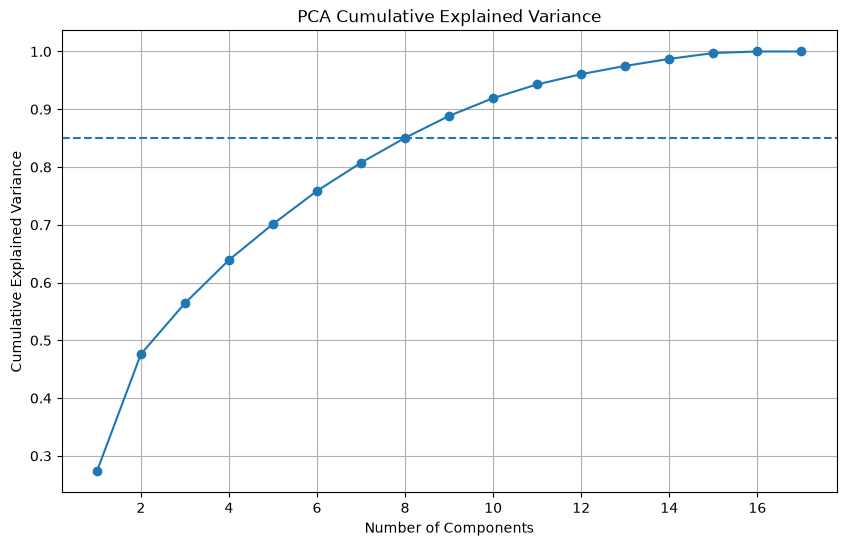

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    components,
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.axhline(
    y=0.85,
    linestyle="--"
)

plt.grid(True)
plt.show()

In [33]:
n_components_85 = (
    cumulative_variance >= 0.85
).argmax() + 1

print("Number of components required for 85% variance:",
      n_components_85)

Number of components required for 85% variance: 8


In [34]:
variance_85 = cumulative_variance[n_components_85 - 1]

print("Components:", n_components_85)
print("Cumulative explained variance:", variance_85)
print("Percentage:", variance_85 * 100)

Components: 8
Cumulative explained variance: 0.8505157155409708
Percentage: 85.05157155409708


In [36]:
 

print(
    "Number of components required for 85% variance:",
    n_components_85
)

print(
    "Cumulative explained variance:",
    cumulative_variance[n_components_85 - 1]
)

print(
    "Cumulative explained variance (%):",
    cumulative_variance[n_components_85 - 1] * 100
)

Number of components required for 85% variance: 8
Cumulative explained variance: 0.8505157155409708
Cumulative explained variance (%): 85.05157155409708


In [38]:
pca_8 = PCA(n_components=8)
X_pca_8 = pca_8.fit_transform(X_scaled)
X_pca_8

array([[-1.68364879, -1.07224148, -0.47566008, ..., -0.06806942,
        -0.82215526, -0.01895178],
       [-1.13408493,  2.50914981, -0.60221631, ...,  1.10225463,
         0.38428208,  0.17615355],
       [ 0.96939499, -0.3835769 , -0.09096976, ...,  0.32018501,
         1.54249644, -0.22936433],
       ...,
       [-0.92898512, -1.80804835,  0.45824238, ..., -2.98078368,
         1.4032653 , -0.29283192],
       [-2.33784475, -0.65361133, -0.98283115, ..., -3.17948406,
         0.97353358,  0.23086252],
       [-0.55802653, -0.4006461 , -1.0336456 , ..., -3.67556151,
         1.4192505 , -0.40444471]], shape=(8950, 8))

In [39]:
pca_8 = PCA(n_components=8)
X_pca_8 = pca_8.fit_transform(X_scaled)

print("PCA shape:", X_pca_8.shape)

PCA shape: (8950, 8)


In [44]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

print("PCA shape:", X_pca_2.shape)

PCA shape: (8950, 2)


In [45]:
print("Explained variance ratio:")
print(pca_2.explained_variance_ratio_)

print("Total variance explained:")
print(pca_2.explained_variance_ratio_.sum())

print("Total variance explained (%):")
print(pca_2.explained_variance_ratio_.sum() * 100)

Explained variance ratio:
[0.27297671 0.2031378 ]
Total variance explained:
0.47611450961284607
Total variance explained (%):
47.6114509612846


In [47]:
pca_2_df = pd.DataFrame(
    X_pca_2,
    columns=["PC1", "PC2"],
    index=data.index
)

pca_2_df.head()

,PC1,PC2
0,-1.683649,-1.072241
1,-1.134085,2.509150
2,0.969395,-0.383577
3,-0.888220,0.004648
4,-1.600021,-0.683795


In [48]:
print("Total variance explained (%):", pca_2.explained_variance_ratio_.sum() * 100)

Total variance explained (%): 47.6114509612846


In [49]:
cov_matrix = X.cov()
cov_matrix

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,4.332775e+06,158.988998,8.061523e+05,5.678461e+05,2.380664e+05,2.168214e+06,-65.119343,45.435849,-52.273592,187.125835,5471.365291,7985.773745,4.024015e+06,1.945257e+06,1.932213e+06,-194.197159,202.504520
BALANCE_FREQUENCY,1.589890e+02,0.056124,6.766297e+01,4.102345e+01,2.662852e+01,4.937859e+01,0.021843,0.014306,0.016579,0.009097,0.228864,1.116684,8.269372e+01,4.458579e+01,7.249678e+01,-0.006589,0.037976
PURCHASES,8.061523e+05,67.662970,4.565208e+06,3.251657e+06,1.313723e+06,-2.306495e+05,337.044946,317.716663,267.979467,-51.371585,-979.535067,36623.760369,2.775302e+06,3.731605e+06,4.774428e+05,112.730411,246.743184
ONEOFF_PURCHASES,5.678461e+05,41.023448,3.251657e+06,2.755228e+06,4.962960e+05,-1.090465e+05,176.509300,259.928390,84.265286,-27.447210,-523.498146,22508.787926,1.931117e+06,2.726109e+06,1.946010e+05,64.458433,142.507934
INSTALLMENTS_PURCHASES,2.380664e+05,26.628521,1.313723e+06,4.962960e+05,8.178274e+05,-1.218410e+05,160.586498,57.747937,183.793384,-23.946638,-456.707265,14119.681306,8.440782e+05,1.005576e+06,2.827303e+05,48.292913,104.259027
CASH_ADVANCE,2.168214e+06,49.378593,-2.306495e+05,-1.090465e+05,-1.218410e+05,4.398096e+06,-181.401230,-54.278472,-147.589949,263.782761,9396.057137,-3954.112719,2.319753e+06,2.751800e+06,6.885713e+05,-93.813403,-191.732461
PURCHASES_FREQUENCY,-6.511934e+01,0.021843,3.370449e+02,1.765093e+02,1.605865e+02,-1.814012e+02,0.161098,0.060033,0.137659,-0.024778,-0.557369,5.671300,1.750098e+02,1.202246e+02,5.761906e+00,0.035901,0.033039
ONEOFF_PURCHASES_FREQUENCY,4.543585e+01,0.014306,3.177167e+02,2.599284e+02,5.774794e+01,-5.427847e+01,0.060033,0.089004,0.016876,-0.006670,-0.140667,4.040714,3.202980e+02,2.103434e+02,-1.900747e+01,0.013747,0.032926
PURCHASES_INSTALLMENTS_FREQUENCY,-5.227359e+01,0.016579,2.679795e+02,8.426529e+01,1.837934e+02,-1.475899e+02,0.137659,0.016876,0.157965,-0.020915,-0.458965,5.235947,8.791833e+01,9.843842e+01,2.972064e+01,0.029073,0.038976
CASH_ADVANCE_FREQUENCY,1.871258e+02,0.009097,-5.137159e+01,-2.744721e+01,-2.394664e+01,2.637828e+02,-0.024778,-0.006670,-0.020915,0.040049,1.092006,-0.652504,9.656095e+01,1.061347e+02,4.697195e+01,-0.014621,-0.035721


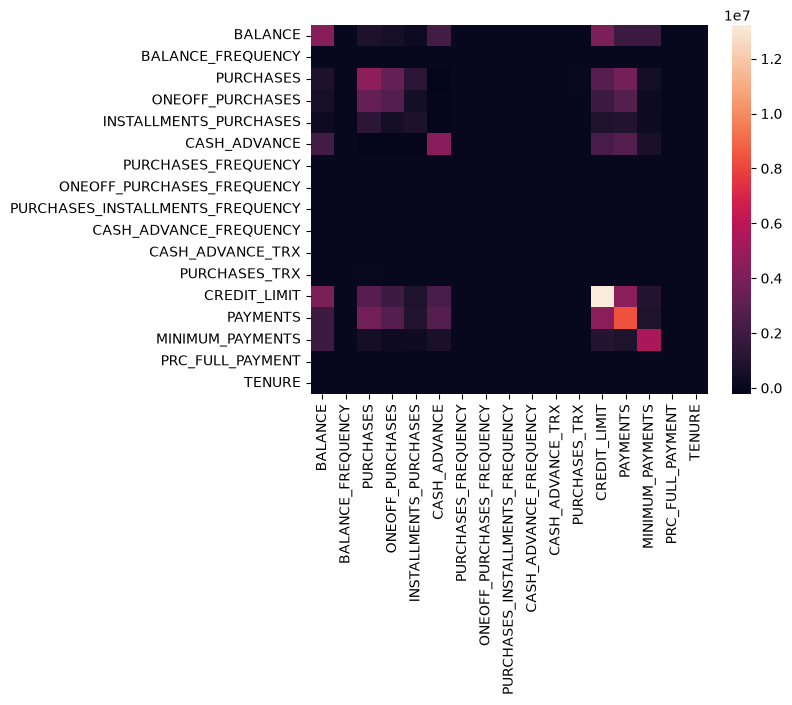

In [51]:
# create heatmap of the covariance 
shape = cov_matrix.shape
x = sns.heatmap(
    cov_matrix,)

In [52]:
X = data.drop(columns=["CUST_ID"])

In [53]:
cov_matrix.max()

BALANCE                             4.332775e+06
BALANCE_FREQUENCY                   1.589890e+02
PURCHASES                           4.565208e+06
ONEOFF_PURCHASES                    3.251657e+06
INSTALLMENTS_PURCHASES              1.313723e+06
CASH_ADVANCE                        4.398096e+06
PURCHASES_FREQUENCY                 3.370449e+02
ONEOFF_PURCHASES_FREQUENCY          3.202980e+02
PURCHASES_INSTALLMENTS_FREQUENCY    2.679795e+02
CASH_ADVANCE_FREQUENCY              2.637828e+02
CASH_ADVANCE_TRX                    9.396057e+03
PURCHASES_TRX                       3.662376e+04
CREDIT_LIMIT                        1.323975e+07
PAYMENTS                            8.381394e+06
MINIMUM_PAYMENTS                    5.441920e+06
PRC_FULL_PAYMENT                    1.127304e+02
TENURE                              6.779730e+02
dtype: float64

In [56]:
import numpy as np

# cov_matrix = X.cov()

# # Remove diagonal values
# cov_matrix_no_diag = cov_matrix.copy()
# np.fill_diagonal(cov_matrix_no_diag.to_numpy(), np.nan)

# # Find maximum covariance
# max_cov = cov_matrix_no_diag.max().max()

# # Find the two columns
# row, col = np.where(cov_matrix_no_diag == max_cov)

# print("Maximum covariance:", max_cov)
# print("Columns:", 
#       cov_matrix_no_diag.index[row[0]], 
#       "and", 
#       cov_matrix_no_diag.columns[col[0]])
cov_matrix_no_diag = cov_matrix.copy()

matrix = cov_matrix_no_diag.to_numpy().copy()

np.fill_diagonal(matrix, np.nan)

cov_matrix_no_diag = pd.DataFrame(
    matrix,
    index=cov_matrix.index,
    columns=cov_matrix.columns
)

In [57]:
max_cov = cov_matrix_no_diag.max().max()

row, col = np.where(cov_matrix_no_diag == max_cov)

print("Maximum covariance:", max_cov)
print(
    "Columns:",
    cov_matrix_no_diag.index[row[0]],
    "and",
    cov_matrix_no_diag.columns[col[0]]
)

Maximum covariance: 4444088.41053235
Columns: CREDIT_LIMIT and PAYMENTS


In [58]:
cov_matrix = X.cov()

# Get only the upper triangle
upper = cov_matrix.where(
    np.triu(np.ones(cov_matrix.shape), k=1).astype(bool)
)

# Find maximum covariance
max_cov = upper.max().max()

# Find the columns
row, col = np.where(upper == max_cov)

print("Maximum covariance:", max_cov)
print(
    "Columns:",
    upper.index[row[0]],
    "and",
    upper.columns[col[0]]
)

Maximum covariance: 4444088.41053235
Columns: CREDIT_LIMIT and PAYMENTS


In [59]:
covariance_matrix = pca.get_covariance()

covariance_df = pd.DataFrame(
    covariance_matrix,
    index=X.columns,
    columns=X.columns
)

covariance_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000112,0.322448,0.181281,0.164368,0.126483,0.496747,-0.077952,0.073174,-0.063193,0.449268,0.385195,0.154356,0.531356,0.322838,0.397965,-0.318995,0.072700
BALANCE_FREQUENCY,0.322448,1.000112,0.133689,0.104335,0.124306,0.099399,0.229741,0.202438,0.176099,0.191894,0.141571,0.189647,0.095942,0.065015,0.131195,-0.095093,0.119789
PURCHASES,0.181281,0.133689,1.000112,0.916947,0.679972,-0.051480,0.393061,0.498485,0.315602,-0.120157,-0.067183,0.689638,0.357017,0.603331,0.095800,0.180399,0.086298
ONEOFF_PURCHASES,0.164368,0.104335,0.916947,1.000112,0.330658,-0.031329,0.264967,0.524950,0.127743,-0.082637,-0.046217,0.545584,0.319771,0.567355,0.050262,0.132778,0.064157
INSTALLMENTS_PURCHASES,0.126483,0.124306,0.679972,0.330658,1.000112,-0.064251,0.442467,0.214066,0.511408,-0.132333,-0.074007,0.628178,0.256543,0.384127,0.134034,0.182590,0.086153
CASH_ADVANCE,0.496747,0.099399,-0.051480,-0.031329,-0.064251,1.000112,-0.215531,-0.086764,-0.177090,0.628592,0.656571,-0.075859,0.304031,0.453289,0.140763,-0.152952,-0.068320
PURCHASES_FREQUENCY,-0.077952,0.229741,0.393061,0.264967,0.442467,-0.215531,1.000112,0.501399,0.863030,-0.308513,-0.203501,0.568493,0.119846,0.103476,0.006155,0.305837,0.061513
ONEOFF_PURCHASES_FREQUENCY,0.073174,0.202438,0.498485,0.524950,0.214066,-0.086764,0.501399,1.000112,0.142345,-0.111728,-0.069096,0.544930,0.295092,0.243564,-0.027314,0.157548,0.082475
PURCHASES_INSTALLMENTS_FREQUENCY,-0.063193,0.176099,0.315602,0.127743,0.511408,-0.177090,0.863030,0.142345,1.000112,-0.262988,-0.169226,0.530034,0.060801,0.085561,0.032059,0.250115,0.073284
CASH_ADVANCE_FREQUENCY,0.449268,0.191894,-0.120157,-0.082637,-0.132333,0.628592,-0.308513,-0.111728,-0.262988,1.000112,0.799650,-0.131183,0.132622,0.183212,0.100628,-0.249801,-0.133387


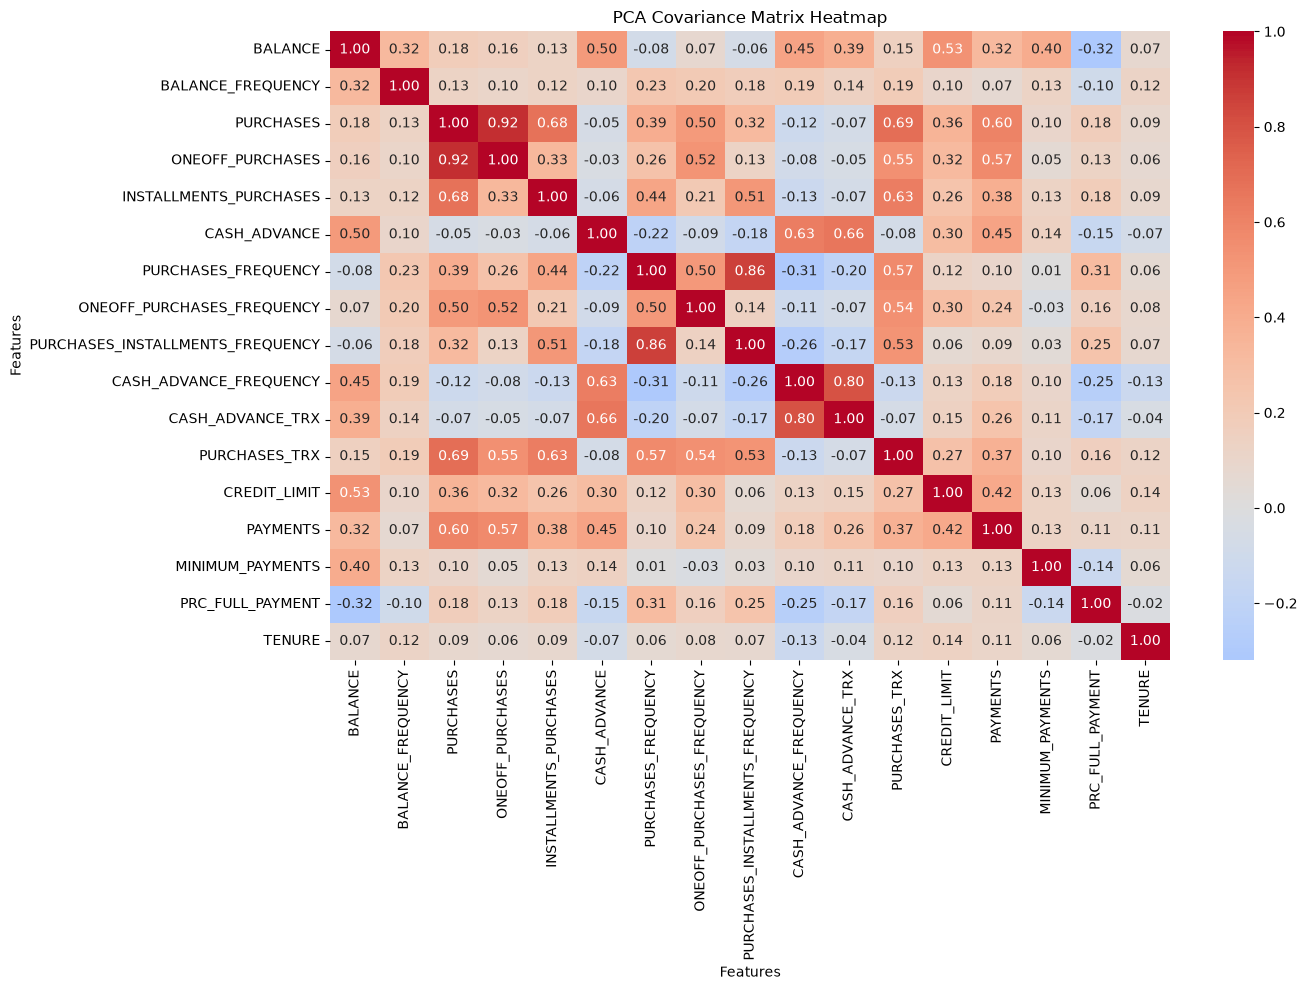

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    covariance_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("PCA Covariance Matrix Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 12):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_pca_2)
    
    inertia.append(kmeans.inertia_)
    


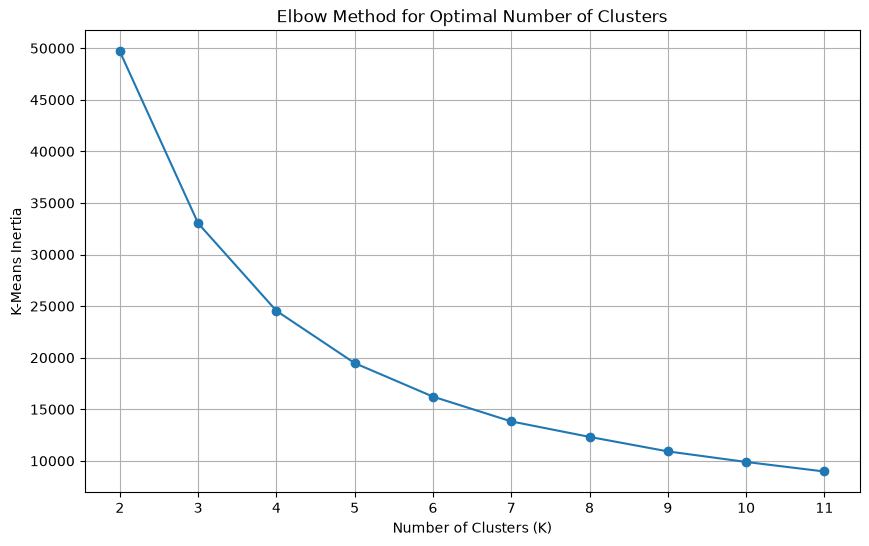

In [62]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(2, 12),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("K-Means Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")

plt.xticks(range(2, 12))
plt.grid(True)

plt.show()

In [63]:
for k, value in zip(range(2, 12), inertia):
    print(f"K = {k}: Inertia = {value:.2f}")

K = 2: Inertia = 49682.23
K = 3: Inertia = 33031.57
K = 4: Inertia = 24544.39
K = 5: Inertia = 19475.95
K = 6: Inertia = 16227.99
K = 7: Inertia = 13824.03
K = 8: Inertia = 12324.67
K = 9: Inertia = 10919.28
K = 10: Inertia = 9894.14
K = 11: Inertia = 8970.18


In [64]:
from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_final.fit(X_pca_2)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)","[[-1.

In [65]:
cluster_labels = kmeans_final.labels_

print(cluster_labels[:20])

[0 2 1 0 0 1 3 1 0 0 1 0 1 1 0 2 0 0 1 1]


In [68]:
data["Cluster"] = cluster_labels

data["Cluster"]


0       0
1       2
2       1
3       0
4       0
       ..
8945    1
8946    1
8947    0
8948    0
8949    0
Name: Cluster, Length: 8950, dtype: int32

In [69]:
cluster_counts = data["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    3918
1    3284
2    1246
3     502
Name: count, dtype: int64


In [70]:
cluster_percentage = (
    data["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print(cluster_percentage)

Cluster
0    43.776536
1    36.692737
2    13.921788
3     5.608939
Name: proportion, dtype: float64


In [74]:
cluster_profile = data.groupby("Cluster").mean(numeric_only=True)

cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,1012.015954,0.799536,222.980202,157.253826,66.055490,613.558647,0.190099,0.074731,0.110111,0.122353,2.259826,2.956100,3108.959503,855.313300,551.136406,0.066146,11.364216
1,825.786010,0.920301,1237.583474,622.592817,615.195740,147.718821,0.862592,0.302365,0.675116,0.030723,0.570037,21.329172,4253.279614,1329.970479,583.423702,0.282922,11.661693
2,4505.865912,0.963515,462.628331,300.247673,162.479912,4400.456157,0.266446,0.129792,0.166388,0.470794,13.773676,6.717496,7449.201080,3542.539456,2060.458227,0.034992,11.439807
3,3407.930310,0.988404,6901.170916,4516.913486,2385.452649,774.694615,0.954352,0.726123,0.808566,0.084975,2.368526,82.980080,9548.705179,6730.862051,1831.212618,0.286595,11.960159


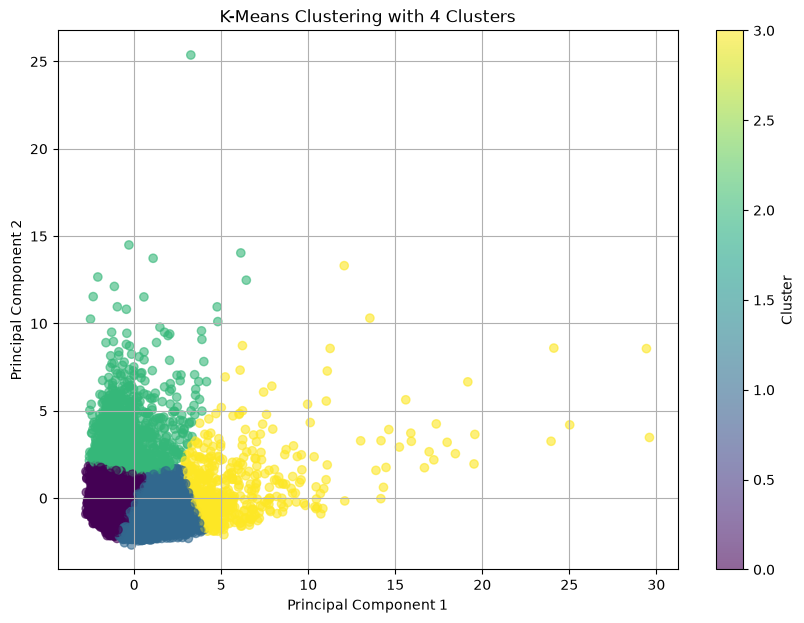

In [75]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=cluster_labels,
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering with 4 Clusters")

plt.colorbar(label="Cluster")
plt.grid(True)

plt.show()

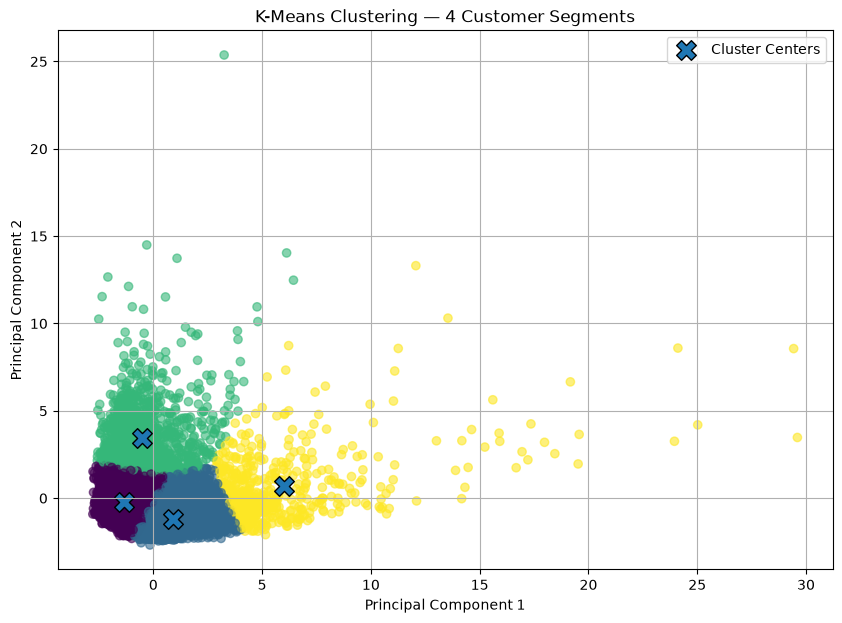

In [76]:
centers = kmeans_final.cluster_centers_

plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=cluster_labels,
    cmap="viridis",
    alpha=0.6
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=200,
    edgecolor="black",
    label="Cluster Centers"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering — 4 Customer Segments")

plt.legend()
plt.grid(True)

plt.show()

In [77]:
print(data["Cluster"].value_counts().sort_index())

Cluster
0    3918
1    3284
2    1246
3     502
Name: count, dtype: int64
